In [1]:
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })


import pandas as pd


# load EOS
m_val, r_val, l_val = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_val.max()
r16 = np.interp(1.6, m_val, r_val)


## Calculate the light curves

In [2]:
df_narrow = pd.read_csv("kn_params_narrow.dat", sep=" ")
df_wide = pd.read_csv("kn_params_wide.dat", sep=" ")

In [3]:
from fiesta.inference.lightcurve_model import BullaFlux

model = BullaFlux(name='Bu2026_MLP',
                  filters=["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"])

def calculate_light_curves(df_in):

    df = df_in.copy()
    df["log10_mej_wind"] = np.maximum(df["log10_mej_wind"], -4)
    df["log10_mej_wind"] = np.minimum(df["log10_mej_wind"], -0.887)

    df["log10_mej_dyn"] = np.maximum(df["log10_mej_dyn"], -4)
    df["log10_mej_dyn"] = np.minimum(df["log10_mej_dyn"], -1.33)

    df["v_ej_dyn"] = np.maximum(df["v_ej_dyn"], 0.12)
    df["v_ej_dyn"] = np.minimum(df["v_ej_dyn"], 0.35)


    kn_parameters = ["inclination_EM", "log10_mej_dyn", "v_ej_dyn", "Ye_dyn", "log10_mej_wind", "v_ej_wind", "Ye_wind", "redshift", "luminosity_distance"]
    params = dict(zip(df[kn_parameters].columns, df[kn_parameters].T.values))
    times, mags = model.vpredict(params)

    return np.array(times), {key: np.array(val) for key, val in mags.items()}



times_wide, mags_wide = calculate_light_curves(df_wide)
times_narrow, mags_narrow = calculate_light_curves(df_narrow)

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
12:29 fiesta INFO    : Loading surrogate Bu2026_MLP. This surrogate should only be used in the following parameter ranges:
12:29 fiesta INFO    : 	 log10_mej_dyn: (-4.0, -1.3010299956639813)
12:29 fiesta INFO    : 	 v_ej_dyn: (0.12, 0.35)
12:29 fiesta INFO    : 	 Ye_dyn: (0.15, 0.35)
12:29 fiesta INFO    : 	 log10_mej_wind: (-4.0, -0.5502131530142267)
12:29 fiesta INFO    : 	 v_ej_wind: (0.05, 0.15)
12:29 fiesta INFO    : 	 Ye_wind: (0.2, 0.4)
12:29 fiesta INFO    : 	 inclination_EM: (0.0, 1.5707963267948966)
12:29 fiesta INFO    : Surrogate Bu2026_MLP is loading with source-frame time range [ 0.19405578 27.52765949] days.
12:29 fiesta INFO    : Surrogate Bu2026_MLP is loading with the following filters: ['lsstu',

In [4]:
def average_mags(times, mag_array, redshift):
    
    mask = redshift < 1.5
    times_mean = np.geomspace(0.2, 20, 80)

    mag_array = mag_array[mask].copy()
    times = times[mask].copy()

    mags_interp = np.zeros((mag_array.shape[0],times_mean.shape[0]))

    for j in range(mag_array.shape[0]):
        mags_interp[j] = np.interp(times_mean, times[j], mag_array[j])

    mags_median = np.median(mags_interp, axis=0)
    mags_lower = np.quantile(mags_interp, q=0.14, axis=0)
    mags_upper = np.quantile(mags_interp, q=0.86, axis=0)

    return times_mean, mags_median, mags_lower, mags_upper
    

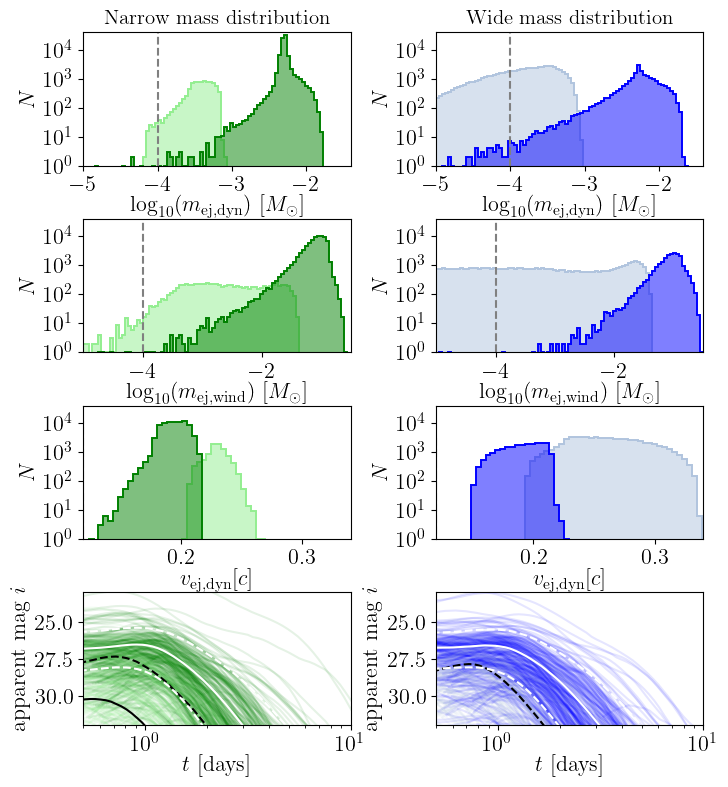

In [5]:
def plot_kn_population(ax, df, times, mags, color, color_pc, filt="lssti"):
    pc = df["prompt_collapse"] <= 1

    ax[0].hist(df["log10_mej_dyn"][pc], bins=np.linspace(-5, -1, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.5), linewidth= 1.4, label="prompt collapse fit", rasterized=True)
    ax[0].hist(df["log10_mej_dyn"][~pc], bins=np.linspace(-5, -1, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.5), linewidth=1.4, label="NS remnant fit", rasterized=True)
    ax[0].set(xlim= (-5, -1.4), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[0].vlines(model.parameter_distributions["log10_mej_dyn"][:2], *ax[0].get_ylim(), color="grey", linestyle="dashed")
    ax[0].set_xlabel("$\\log_{10}(m_{\\mathrm{ej, dyn}})$ [$M_\\odot$]", labelpad=0)
    ax[0].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[0].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))
    
    ax[1].hist(df["log10_mej_wind"][pc], bins=np.linspace(-5, -0, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.5), linewidth= 1.4, label="prompt collapse fit", rasterized=True)
    ax[1].hist(df["log10_mej_wind"][~pc], bins=np.linspace(-5, -0, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.5), linewidth= 1.4, label="NS remnant fit", rasterized=True)
    ax[1].set(xlim= (-5, -0.5), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[1].vlines(model.parameter_distributions["log10_mej_wind"][:1], *ax[1].get_ylim(), color="grey", linestyle="dashed")
    ax[1].set_xlabel("$\\log_{10}(m_{\\mathrm{ej, wind}})$ [$M_\\odot$]", labelpad=0)
    ax[1].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[1].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))
    
    ax[2].hist(df["v_ej_dyn"][pc], bins=np.linspace(0.1, 0.5, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.5), linewidth= 1.4, label="prompt collapse fit", rasterized=True)
    ax[2].hist(df["v_ej_dyn"][~pc], bins=np.linspace(0.1, 0.5, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.5), linewidth= 1.4, label="NS remnant fit", rasterized=True)
    ax[2].vlines(model.parameter_distributions["v_ej_dyn"][:2], *ax[2].get_ylim(), color="grey", linestyle="dashed")
    ax[2].set(xlim= (0.12, 0.34), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[2].set_xlabel("$v_{\\mathrm{ej, dyn}} [c]$", labelpad=0)
    ax[2].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[2].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))

   
    times_median, median_nopc, upper_nopc, lower_nopc = average_mags(times[~pc], mags[filt][~pc], df["redshift"][~pc])
    times_median, median_pc, upper_pc, lower_pc = average_mags(times[pc], mags[filt][pc], df["redshift"][pc])
    
    inds = np.random.choice(np.arange(mags[filt][~pc].shape[0]), replace=False, size=300)
    for ind in inds:
        ax[3].plot(times[~pc][ind], mags[filt][~pc][ind], color=color, rasterized=True, alpha=0.1)
    inds = np.random.choice(np.arange(mags[filt][pc].shape[0]), replace=False, size=300)
    for ind in inds:
        ax[3].plot(times[pc][ind], mags[filt][pc][ind], color=color_pc, rasterized=True, alpha=0.1)
    
    ax[3].plot(times_median, median_pc, color="black")
    ax[3].plot(times_median, upper_pc, color="black", linestyle="dashed")
    ax[3].plot(times_median, lower_pc, color="black", linestyle="dashed")
    ax[3].plot(times_median, median_nopc, color="white")
    ax[3].plot(times_median, upper_nopc, color="white", linestyle="dashed")
    ax[3].plot(times_median, lower_nopc, color="white", linestyle="dashed")
    
    ax[3].set(xscale="log", xlim=(0.5, 10))
    ax[3].set_xlabel("$t$ [days]", labelpad=0)
    ax[3].set_ylim((32, 23))
    ax[3].set_ylabel(f"apparent mag ${filt[-1]}$")
    ax[3].yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))


fig, ax = plt.subplots(4,2, figsize=(8, 9))
fig.subplots_adjust(hspace=0.4, wspace=0.32)

plot_kn_population(ax[:, 0], df_narrow, times_narrow, mags_narrow, color=(0., 0.5, 0), color_pc=(0.5747, 0.9333, 0.5647))
plot_kn_population(ax[:, 1], df_wide, times_wide, mags_wide, color=(0, 0, 1.0), color_pc=(0.6902, 0.7686, 0.8706))

ax[0,0].set_title("Narrow mass distribution", fontsize=15)
ax[0,1].set_title("Wide mass distribution", fontsize=15)

fig.savefig('../../figures/kn_population.pdf', dpi=250, bbox_inches="tight")

# One column figure attempt

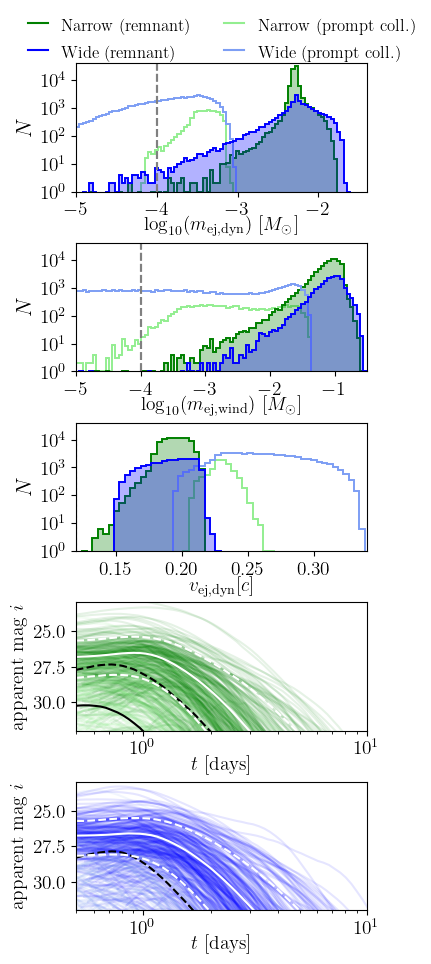

In [23]:
def plot_kn_population_one_column(ax, df, label, color, color_pc):
    pc = df["prompt_collapse"] <= 1

    ax[0].hist(df["log10_mej_dyn"][pc], bins=np.linspace(-5, -1, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.), linewidth= 1.4, rasterized=True)
    ax[0].hist(df["log10_mej_dyn"][~pc], bins=np.linspace(-5, -1, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.3), linewidth=1.4, label=label, rasterized=True)
    ax[0].set_xticks([-5, -4, -3, -2, -1], minor=False)
    ax[0].tick_params(axis="both", which="major", labelsize=14)
    ax[0].set(xlim= (-5, -1.4), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[0].vlines(model.parameter_distributions["log10_mej_dyn"][:2], *ax[0].get_ylim(), color="grey", linestyle="dashed")
    ax[0].set_xlabel("$\\log_{10}(m_{\\mathrm{ej, dyn}})$ [$M_\\odot$]", labelpad=-2, fontsize=14)
    ax[0].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[0].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))
    
    ax[1].hist(df["log10_mej_wind"][pc], bins=np.linspace(-5, -0, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.), linewidth= 1.4, rasterized=True)
    ax[1].hist(df["log10_mej_wind"][~pc], bins=np.linspace(-5, -0, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.3), linewidth= 1.4, rasterized=True)
    ax[1].set_xticks([-5, -4, -3, -2, -1], minor=False)
    ax[1].tick_params(axis="both", which="major", labelsize=14)
    ax[1].set(xlim= (-5, -0.5), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[1].vlines(model.parameter_distributions["log10_mej_wind"][:1], *ax[1].get_ylim(), color="grey", linestyle="dashed")
    ax[1].set_xlabel("$\\log_{10}(m_{\\mathrm{ej, wind}})$ [$M_\\odot$]", labelpad=-2, fontsize=14)
    ax[1].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[1].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))

    ax[2].hist(df["v_ej_dyn"][pc], bins=np.linspace(0.1, 0.5, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.), linewidth= 1.4, rasterized=True)
    ax[2].hist(df["v_ej_dyn"][~pc], bins=np.linspace(0.1, 0.5, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.3), linewidth= 1.4, rasterized=True)
    ax[2].vlines(model.parameter_distributions["v_ej_dyn"][:2], *ax[2].get_ylim(), color="grey", linestyle="dashed")
    ax[2].set_xticks([0.15, 0.2, 0.25, 0.3, 0.35], minor=False)
    ax[2].tick_params(axis="both", which="major", labelsize=14)
    ax[2].set(xlim= (0.12, 0.34), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[2].set_xlabel("$v_{\\mathrm{ej, dyn}} [c]$", labelpad=-1,fontsize=14)
    ax[2].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[2].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))


def plot_kn_mags(ax, df, times, mags, color, color_pc, filt="lssti"):

    pc = df["prompt_collapse"] <= 1
    times_median, median_nopc, upper_nopc, lower_nopc = average_mags(times[~pc], mags[filt][~pc], df["redshift"][~pc])
    times_median, median_pc, upper_pc, lower_pc = average_mags(times[pc], mags[filt][pc], df["redshift"][pc])
    
    inds = np.random.choice(np.arange(mags[filt][~pc].shape[0]), replace=False, size=300)
    for ind in inds:
        ax.plot(times[~pc][ind], mags[filt][~pc][ind], color=color, rasterized=True, alpha=0.1)
    inds = np.random.choice(np.arange(mags[filt][pc].shape[0]), replace=False, size=300)
    for ind in inds:
        ax.plot(times[pc][ind], mags[filt][pc][ind], color=color_pc, rasterized=True, alpha=0.1)
    
    ax.plot(times_median, median_pc, color="black")
    ax.plot(times_median, upper_pc, color="black", linestyle="dashed")
    ax.plot(times_median, lower_pc, color="black", linestyle="dashed")
    ax.plot(times_median, median_nopc, color="white")
    ax.plot(times_median, upper_nopc, color="white", linestyle="dashed")
    ax.plot(times_median, lower_nopc, color="white", linestyle="dashed")

    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.set(xscale="log", xlim=(0.5, 10))
    ax.set_xlabel("$t$ [days]", labelpad=-2, fontsize=14)
    ax.set_ylim((32, 23))
    ax.set_ylabel(f"apparent mag ${filt[-1]}$", fontsize=14)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))


fig, ax = plt.subplots(5,1, figsize=(3.75, 11))
fig.subplots_adjust(hspace=0.4, wspace=0.32)

plot_kn_population_one_column(ax, df_narrow, label="Narrow", color=(0., 0.5, 0), color_pc=(0.5747, 0.9333, 0.5647))
plot_kn_population_one_column(ax, df_wide, label="Wide", color=(0, 0, 1.0), color_pc=(125/256, 159/256, 245/256))

plot_kn_mags(ax[3], df_narrow, times_narrow, mags_narrow, color=(0., 0.5, 0), color_pc=(0.5747, 0.9333, 0.5647))
plot_kn_mags(ax[4], df_wide, times_wide, mags_wide, color=(0, 0, 1.0), color_pc=(125/256, 159/256, 245/256))


lc1 = plt.plot([], [], color=(0., 0.5, 0))[0]
lc2 = plt.plot([], [], color=(0., 0., 1.))[0]
lc3 = plt.plot([], [], color=(0.5747, 0.9333, 0.5647))[0]
lc4 = plt.plot([], [], color=(125/256, 159/256, 245/256))[0]
ax[0].legend([lc1, lc2, lc3, lc4], 
             ["Narrow (remnant)", "Wide (remnant)", "Narrow (prompt coll.)", "Wide (prompt coll.)"], 
             handlelength=1.2, handleheight=1.2, fontsize=12,
             bbox_to_anchor=[0.5, 0.9], loc='lower center', frameon=False, ncol=2)
fig.savefig('../../figures/kn_population.pdf', dpi=250, bbox_inches="tight")

## Sandbox

In [ ]:
df_wide_gw = pd.read_csv("../gw/gw_params_wide.dat", sep=" ")
df_narrow_gw = pd.read_csv("../gw/gw_params_narrow.dat", sep=" ")

/tmp/ipykernel_47382/1693990916.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


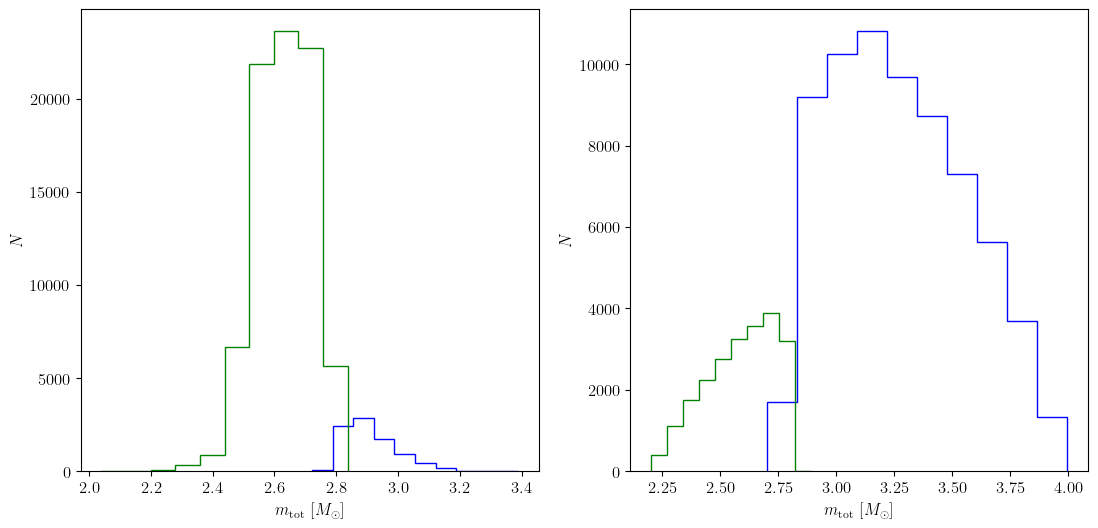

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(13, 6) )

pc = df_narrow_gw["prompt_collapse"] <=1
ax[0].hist(df_narrow_gw["mass_1_source"][pc] + df_narrow_gw["mass_2_source"][pc], color="blue", histtype="step")
ax[0].hist(df_narrow_gw["mass_1_source"][~pc]+ df_narrow_gw["mass_2_source"][~pc], color="green", histtype="step")
ax[0].set(xlabel="$m_{\\mathrm{tot}}$ [$M_\\odot$]", ylabel="$N$")

pc = df_wide_gw["prompt_collapse"] <=1
ax[1].hist(df_wide_gw["mass_1_source"][pc]+ df_wide_gw["mass_2_source"][pc], color="blue", histtype="step")
ax[1].hist(df_wide_gw["mass_1_source"][~pc]+ df_wide_gw["mass_2_source"][~pc], color="green", histtype="step")
ax[1].set(xlabel="$m_{\\mathrm{tot}}$ [$M_\\odot$]", ylabel="$N$")

fig.show()

/tmp/ipykernel_47382/3734034626.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


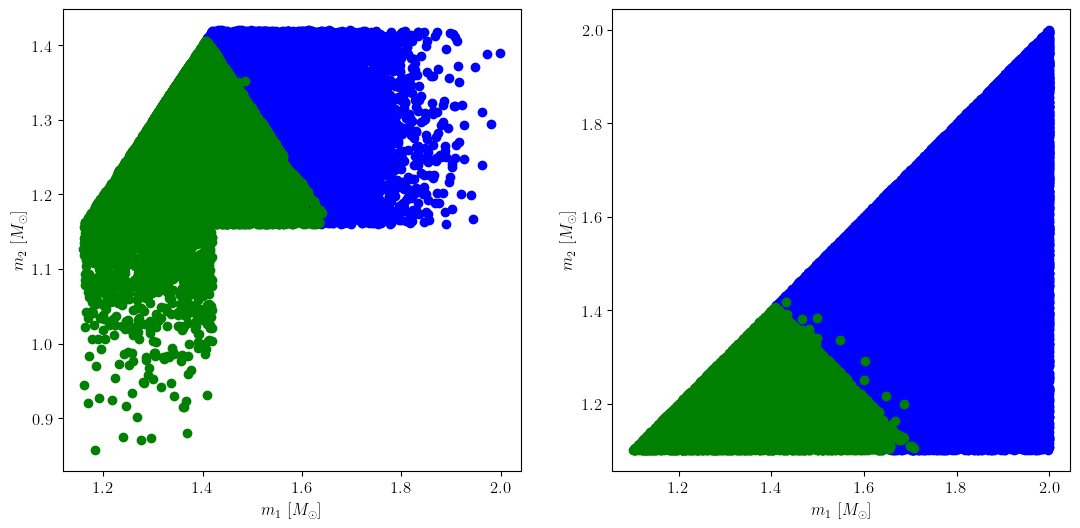

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(13, 6) )

pc = df_narrow_gw["prompt_collapse"] <=1
ax[0].scatter(df_narrow_gw["mass_1_source"][pc], df_narrow_gw["mass_2_source"][pc], color="blue")
ax[0].scatter(df_narrow_gw["mass_1_source"][~pc], df_narrow_gw["mass_2_source"][~pc], color="green")
ax[0].set(xlabel="$m_1$ [$M_\\odot$]", ylabel="$m_2$ [$M_\\odot$]")

pc = df_wide_gw["prompt_collapse"] <=1
ax[1].scatter(df_wide_gw["mass_1_source"][pc], df_wide_gw["mass_2_source"][pc], color="blue")
ax[1].scatter(df_wide_gw["mass_1_source"][~pc], df_wide_gw["mass_2_source"][~pc], color="green")
ax[1].set(xlabel="$m_1$ [$M_\\odot$]", ylabel="$m_2$ [$M_\\odot$]")

fig.show()

In [34]:
model.parameter_distributions

{'log10_mej_dyn': (-4.0, -1.3010299956639813, 'uniform'),
 'v_ej_dyn': (0.12, 0.35, 'uniform'),
 'Ye_dyn': (0.15, 0.35, 'uniform'),
 'log10_mej_wind': (-4.0, -0.8860566476931632, 'uniform'),
 'v_ej_wind': (0.05, 0.15, 'uniform'),
 'Ye_wind': (0.2, 0.4, 'uniform'),
 'inclination_EM': (0.0, 1.5707963267948966, 'uniform')}

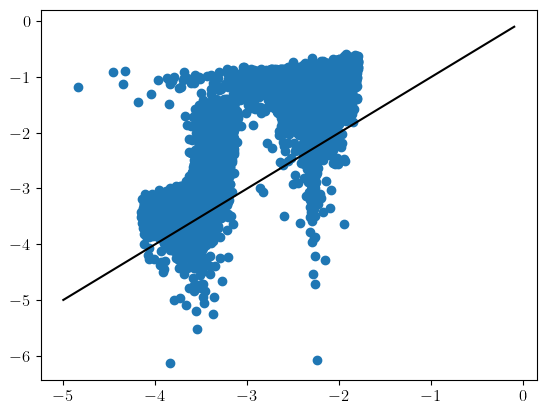

In [42]:
plt.scatter(x=df_narrow["log10_mej_dyn"], y=df_narrow["log10_mej_wind"])
plt.plot(np.arange(-5, 0, 0.1), np.arange(-5, 0, 0.1), color="black")

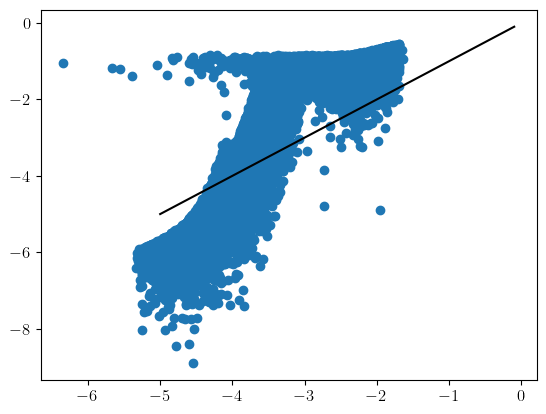

In [43]:
plt.scatter(x=df_wide["log10_mej_dyn"], y=df_wide["log10_mej_wind"])
plt.plot(np.arange(-5, 0, 0.1), np.arange(-5, 0, 0.1), color="black")

In [77]:
np.mean(10**df_narrow["log10_mej_wind"] + 10**df_narrow["log10_mej_dyn"]), np.std(10**df_narrow["log10_mej_wind"] + 10**df_narrow["log10_mej_dyn"])

(np.float64(0.08206356853029802), np.float64(0.03885280642779081))

In [91]:
np.log10(10**df_narrow["log10_mej_wind"] + 10**df_narrow["log10_mej_dyn"]).min()

np.float64(-3.8561442692008674)

In [95]:
np.sum(np.log10(10**df_narrow["log10_mej_wind"] + 10**df_narrow["log10_mej_dyn"]) < -3) /df_wide.shape[0]

np.float64(0.021533532206386034)

(array([  11.,   33.,   54.,   92.,  135.,  191.,  213.,  255.,  328.,
         374.,  399.,  458.,  542.,  622.,  621.,  722.,  845.,  827.,
         902.,  990., 1047., 1183., 1223., 1251., 1299., 1334., 1301.,
        1413., 1417., 1338., 1378., 1382., 1325., 1365., 1314., 1262.,
        1220., 1141., 1119., 1131., 1133., 1024.,  969.,  983.,  919.,
         974.,  903.,  882.,  886.,  821.,  767.,  718.,  799.,  697.,
         689.,  627.,  666.,  639.,  631.,  599.,  612.,  580.,  627.,
         604.,  607.,  637.,  648.,  644.,  676.,  776.,  811.,  902.,
         979., 1069., 1178., 1291., 1396., 1381., 1303., 1103.,  856.,
         583.,  422.,  611.,  839., 1059., 1313., 1696., 2060., 2430.,
        2610., 2447., 2265., 1201.,  736.,  522.,  356.,  202.,   82.,
          13.]),
 array([-5.29579631, -5.24805327, -5.20031024, -5.1525672 , -5.10482417,
        -5.05708113, -5.0093381 , -4.96159506, -4.91385203, -4.86610899,
        -4.81836595, -4.77062292, -4.72287988, -4.675136

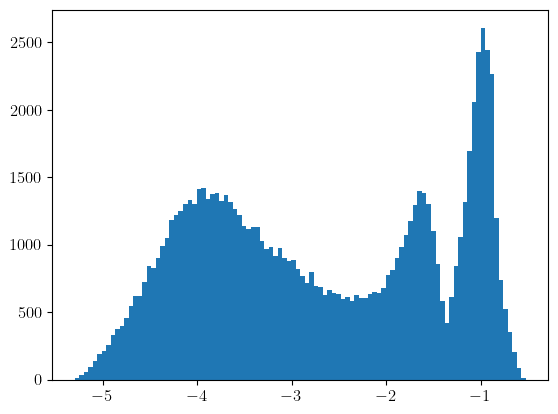

In [84]:
plt.hist(np.log10(10**df_wide["log10_mej_wind"] + 10**df_wide["log10_mej_dyn"]), bins=100)

In [62]:
np.sum(df_narrow["prompt_collapse"] <=1) / df_narrow.shape[0]

np.float64(0.09623246050160203)

In [63]:
np.sum(df_wide["prompt_collapse"] <=1) / df_wide.shape[0]

np.float64(0.7548668655397194)

In [76]:
np.sum(np.min(mags_narrow["lssti"], axis=1) < 26)

np.int64(13571)

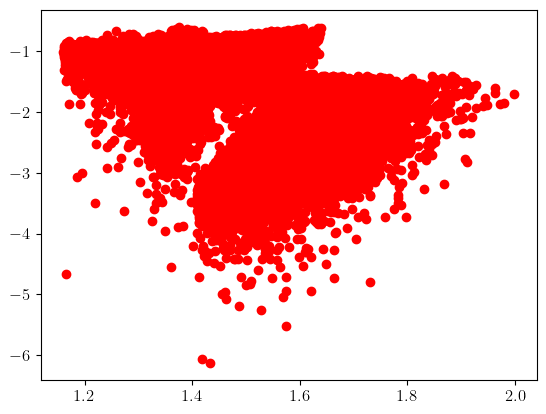

In [113]:
plt.scatter(x=df_narrow_gw["mass_1_source"] , y=df_narrow["log10_mej_wind"], color="red")
#plt.plot(np.arange(-5, 0, 0.1), np.arange(-5, 0, 0.1), color="black")

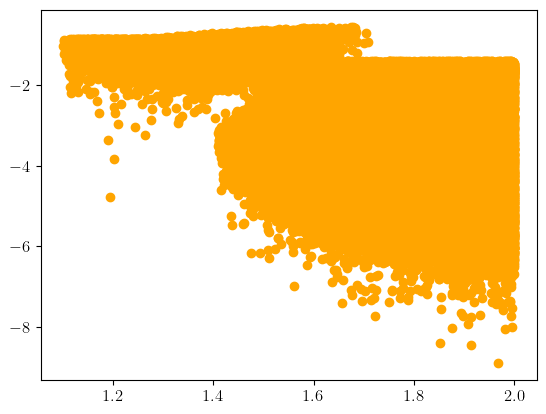

In [112]:
plt.scatter(x=df_wide_gw["mass_1_source"] , y=df_wide["log10_mej_wind"], color="orange")
